# Phase 2 — Exploratory Data Analysis

Real Bengaluru traffic-police parking-violation records, Nov 2023 - Apr 2024 (298,450 rows). Internal-data-only per DECISIONS.md ADR-001 — every chart below is built strictly from the 24 provided columns.

In [1]:
import sys
sys.path.insert(0, "../../backend")

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from app.ingestion.load_data import load_raw_violations

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 30)

df = load_raw_violations()
print(df.shape)
df.head()


(298450, 24)


,id,latitude,longitude,location,vehicle_number,vehicle_type,description,violation_type,offence_code,created_datetime,closed_datetime,modified_datetime,device_id,created_by_id,center_code,police_station,data_sent_to_scita,junction_name,action_taken_timestamp,data_sent_to_scita_timestamp,updated_vehicle_number,updated_vehicle_type,validation_status,validation_timestamp
0,FKID000000,12.925557,77.618665,"18th Main Road, Block 2, Koramangala, Bengalur...",FKN00GL0000,CAR,<NA>,"[""WRONG PARKING"",""PARKING NEAR ROAD CROSSING""]","[112,104]",2023-11-20 00:28:46+00:00,NaT,2023-11-28 04:48:04.582978+00:00,FKDEV00000,FKUSR00000,9,Madiwala,TRUE,No Junction,NaT,NaT,FKN00GL0000,MAXI-CAB,approved,2023-11-30 03:08:24.818000+00:00
1,FKID000001,12.905463,77.700778,"Sarjapura Main Road, The Grove, Janatha Colony...",FKN00GL0001,CAR,<NA>,"[""NO PARKING""]",[113],2023-11-24 22:46:46+00:00,NaT,2023-11-24 23:00:24.115257+00:00,FKDEV00001,FKUSR00001,82,Bellandur,FALSE,No Junction,NaT,NaT,<NA>,<NA>,<NA>,NaT
2,FKID000002,12.925449,77.618504,"Koramangala 2nd Block, Kormangala West, Bengal...",FKN00GL0002,CAR,<NA>,"[""WRONG PARKING"",""PARKING IN A MAIN ROAD""]","[112,107]",2023-11-20 00:27:46+00:00,NaT,2023-11-28 04:47:02.337760+00:00,FKDEV00000,FKUSR00000,9,Madiwala,TRUE,No Junction,NaT,NaT,FKN00GL0002,MAXI-CAB,approved,2023-11-30 03:08:56.998000+00:00
3,FKID000003,12.956521,77.518618,"6th Cross Road, Manasa Layout, Nagarbhavi, Ben...",FKN00GL0003,SCOOTER,<NA>,"[""NO PARKING""]",[113],2023-11-16 06:47:46+00:00,NaT,2023-11-18 04:46:57.216868+00:00,FKDEV00002,FKUSR00002,26,Byatarayanapura,TRUE,No Junction,NaT,NaT,FKN00GL0003,SCOOTER,approved,2023-11-18 23:35:12.428000+00:00
4,FKID000004,12.977767,77.580545,"Kalidasa Road, Gandhinagar, Nehru Nagar, Benga...",FKN00GL0004,TANKER,<NA>,"[""NO PARKING""]",[113],2023-11-22 04:56:46+00:00,NaT,2023-11-28 02:44:50.467370+00:00,FKDEV00003,FKUSR00003,3,Upparpet,TRUE,BTP044 - Sagar Theatre Junction,NaT,NaT,FKN00GL0004,TANKER,approved,2023-11-30 03:11:32.796000+00:00


## 1. Volume over time
Monthly and daily row counts — confirms the actual date range (useful sanity check before picking forecast windows in Phase 4).

C:\Users\kshit\AppData\Local\Temp\ipykernel_24044\4245242948.py:1: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  monthly = df["created_datetime"].dropna().dt.to_period("M").value_counts().sort_index()


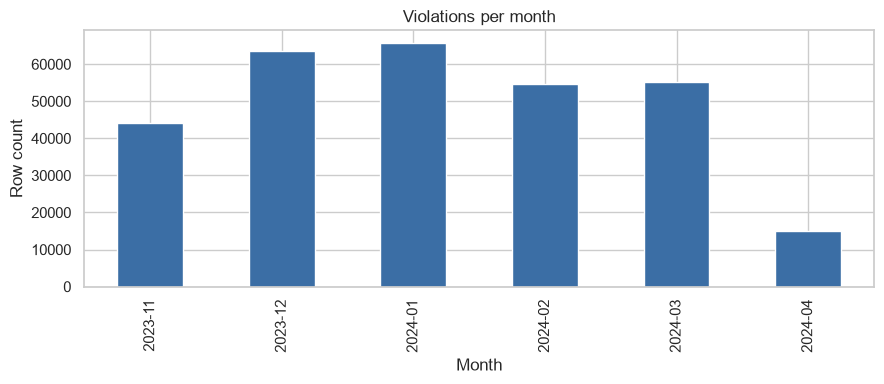

In [2]:
monthly = df["created_datetime"].dropna().dt.to_period("M").value_counts().sort_index()
fig, ax = plt.subplots(figsize=(9, 4))
monthly.plot(kind="bar", ax=ax, color="#3b6ea5")
ax.set_title("Violations per month")
ax.set_xlabel("Month")
ax.set_ylabel("Row count")
plt.tight_layout()
plt.show()


## 2. Time-of-day and day-of-week patterns

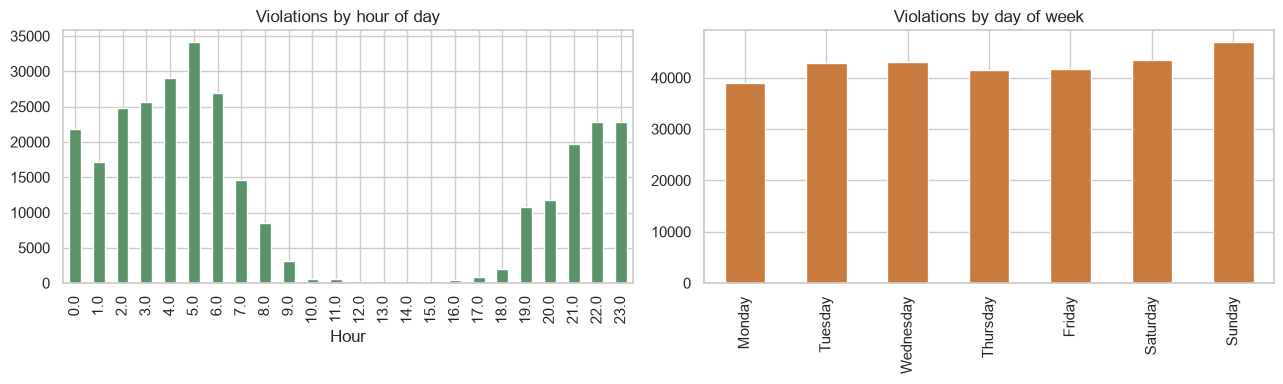

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

hour_counts = df["created_datetime"].dt.hour.value_counts().sort_index()
hour_counts.plot(kind="bar", ax=axes[0], color="#5a9367")
axes[0].set_title("Violations by hour of day")
axes[0].set_xlabel("Hour")

weekday_counts = df["created_datetime"].dt.day_name().value_counts().reindex(
    ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
)
weekday_counts.plot(kind="bar", ax=axes[1], color="#c97a3d")
axes[1].set_title("Violations by day of week")
axes[1].set_xlabel("")

plt.tight_layout()
plt.show()


## 3. Violation type and vehicle type distribution

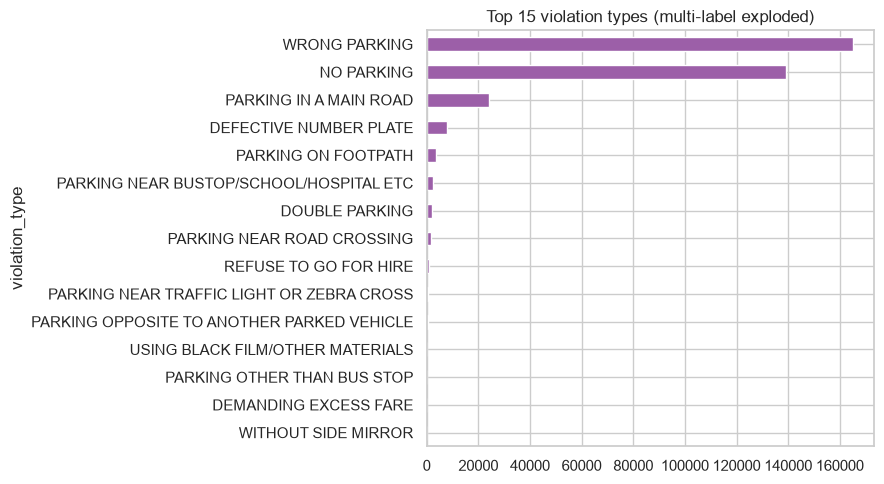

In [4]:
import ast

def parse_list(v):
    if pd.isna(v):
        return []
    try:
        parsed = ast.literal_eval(v)
        return parsed if isinstance(parsed, list) else [parsed]
    except Exception:
        return []

violation_types = df["violation_type"].apply(parse_list).explode()
top_violations = violation_types.value_counts().head(15)

fig, ax = plt.subplots(figsize=(9, 5))
top_violations.sort_values().plot(kind="barh", ax=ax, color="#9c5fa8")
ax.set_title("Top 15 violation types (multi-label exploded)")
plt.tight_layout()
plt.show()


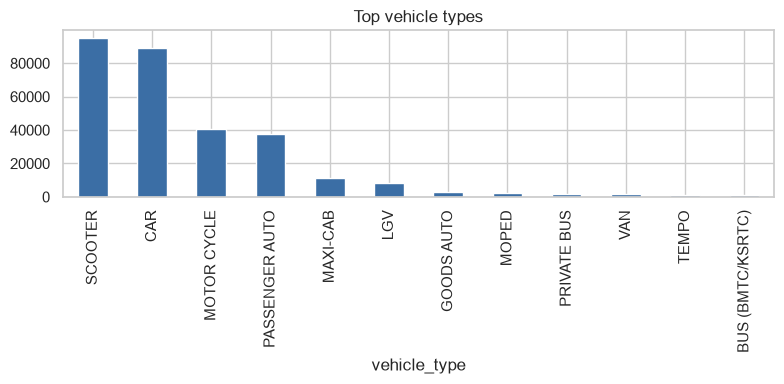

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
df["vehicle_type"].value_counts().head(12).plot(kind="bar", ax=ax, color="#3b6ea5")
ax.set_title("Top vehicle types")
plt.tight_layout()
plt.show()


## 4. Spatial spread — raw lat/lon scatter
Quick look before H3 binning (done in the feature pipeline, not here).

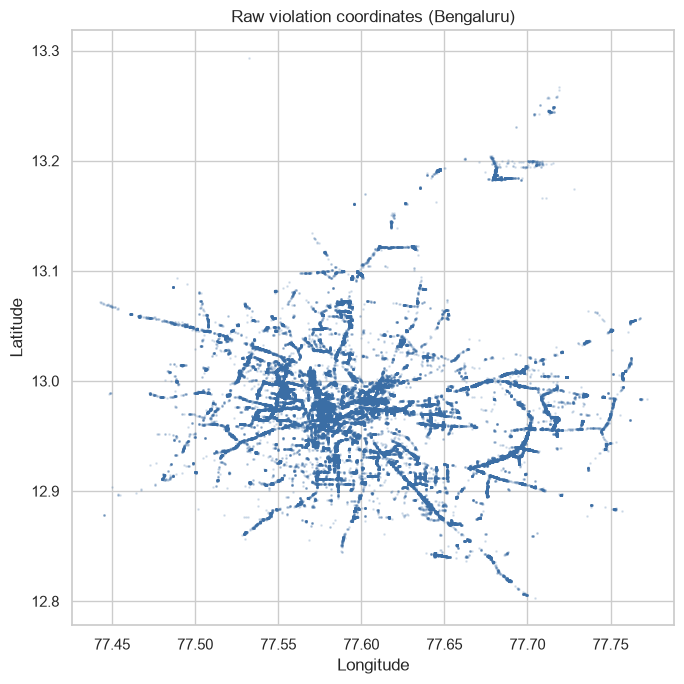

In [6]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(df["longitude"], df["latitude"], s=1, alpha=0.15, color="#3b6ea5")
ax.set_title("Raw violation coordinates (Bengaluru)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()


## 5. Missingness overview
Confirms the data_quality_report.md finding: `closed_datetime` and `action_taken_timestamp` are entirely missing in this extract.

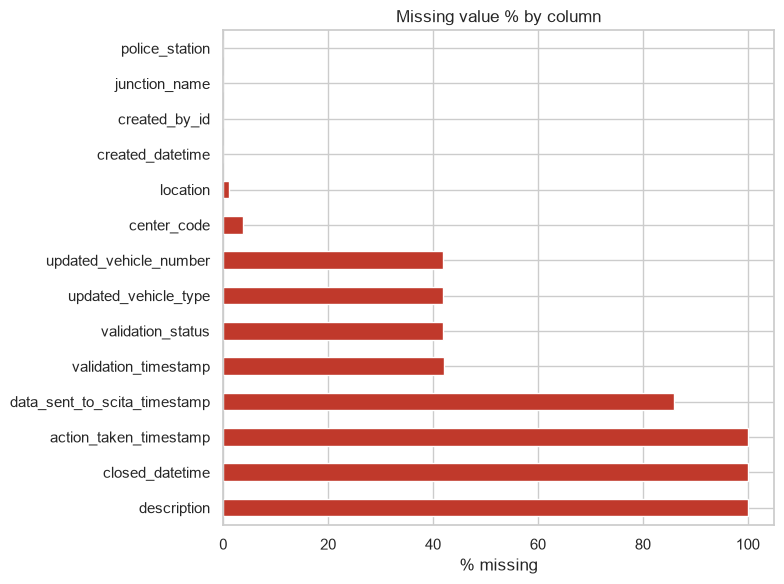

description                     100.000000
closed_datetime                 100.000000
action_taken_timestamp          100.000000
data_sent_to_scita_timestamp     85.873346
validation_timestamp             42.023790
validation_status                41.968169
updated_vehicle_type             41.968169
updated_vehicle_number           41.968169
center_code                       3.772826
location                          1.018931
created_datetime                  0.001675
created_by_id                     0.001675
junction_name                     0.001675
police_station                    0.001675
dtype: float64

In [7]:
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]

fig, ax = plt.subplots(figsize=(8, 6))
missing_pct.plot(kind="barh", ax=ax, color="#c0392b")
ax.set_title("Missing value % by column")
ax.set_xlabel("% missing")
plt.tight_layout()
plt.show()

missing_pct


## 6. Validation status breakdown

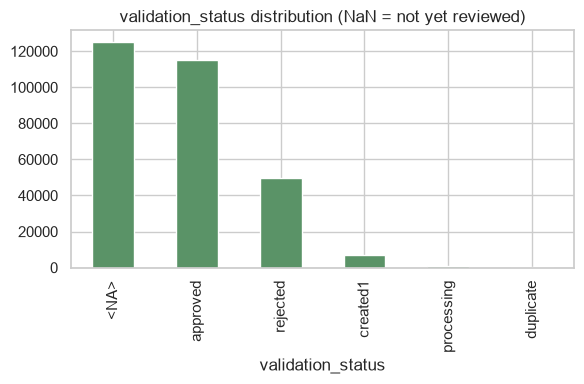

In [8]:
fig, ax = plt.subplots(figsize=(6, 4))
df["validation_status"].value_counts(dropna=False).plot(kind="bar", ax=ax, color="#5a9367")
ax.set_title("validation_status distribution (NaN = not yet reviewed)")
plt.tight_layout()
plt.show()


## Takeaways for feature engineering
- Real date range is **2023-11-09 to 2024-04-08**, not literally "Jan-May" as the filename suggests.
- Clear hour-of-day and day-of-week structure exists → justifies `hour_sin`/`hour_cos`/`is_peak_hour`/`weekday`.
- `closed_datetime` and `action_taken_timestamp` are 100% missing → `resolution_time_minutes` is uncomputable in this extract (documented in feature_dictionary.md).
- Violations are multi-label (`violation_type` is a list) → handled via `primary_violation_type` + `num_offences` in cleaning.py.
- Spatial spread is concentrated, not uniform across Bengaluru → supports H3-based hotspot features.